# 1. Khai báo thư viện và đọc dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Đọc dữ liệu
df = pd.read_csv('../data/train_data.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30682 entries, 0 to 30681
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_total        30682 non-null  int64  
 1   area               30682 non-null  float64
 2   price_per_m2       30682 non-null  float64
 3   category           30682 non-null  object 
 4   latitude           30682 non-null  float64
 5   longitude          30682 non-null  float64
 6   district           30682 non-null  object 
 7   province           30682 non-null  object 
 8   legal_status       30682 non-null  object 
 9   frontage           30682 non-null  float64
 10  road_width         30682 non-null  float64
 11  num_bedrooms       30682 non-null  int64  
 12  num_toilets        30682 non-null  int64  
 13  num_floors         30682 non-null  int64  
 14  num_schools_1km    30682 non-null  int64  
 15  num_hospitals_2km  30682 non-null  int64  
 16  num_markets_1km    306

# 2. Tiền xử lý dữ liệu

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Lựa chọn các biến độc lập (X) và biến phụ thuộc (y)
X = df.drop(columns=['price_total', 'price_billion', 'price_per_m2'])
y = df['price_billion'] # Dự đoán giá theo đơn vị Tỷ VNĐ

# Chia dữ liệu thành tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tự động nhận diện cột dạng số và dạng phân loại
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Tạo Pipeline xử lý số
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Tạo Pipeline xử lý phân loại
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gộp các Pipeline lại
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Đã thiết lập xong quy trình tiền xử lý dữ liệu!")

Đã thiết lập xong quy trình tiền xử lý dữ liệu!


# 3. Trích xuất hệ số bằng Ridge Regression

Training Ridge Regression to extract weights...

REGRESSION COEFFICIENTS TABLE (TOP 10):


,Feature,Coefficient
17,district_Huyện Ba Vì,-11.944989
22,district_Huyện Củ Chi,-11.337594
77,district_Quận Tây Hồ,10.479350
13,"category_Nhà biệt thự, liền kề",8.219361
23,district_Huyện Dầu Tiếng,-8.158186
26,district_Huyện Hòa Vang,-7.068587
55,district_Quận Ba Đình,6.344960
68,district_Quận Long Biên,6.079484
80,district_Thành phố Dĩ An,5.877042
45,district_Quận 1,5.553917


C:\Users\84333\AppData\Local\Temp\ipykernel_18588\959642074.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Coefficient', y='Feature', palette=colors.tolist())


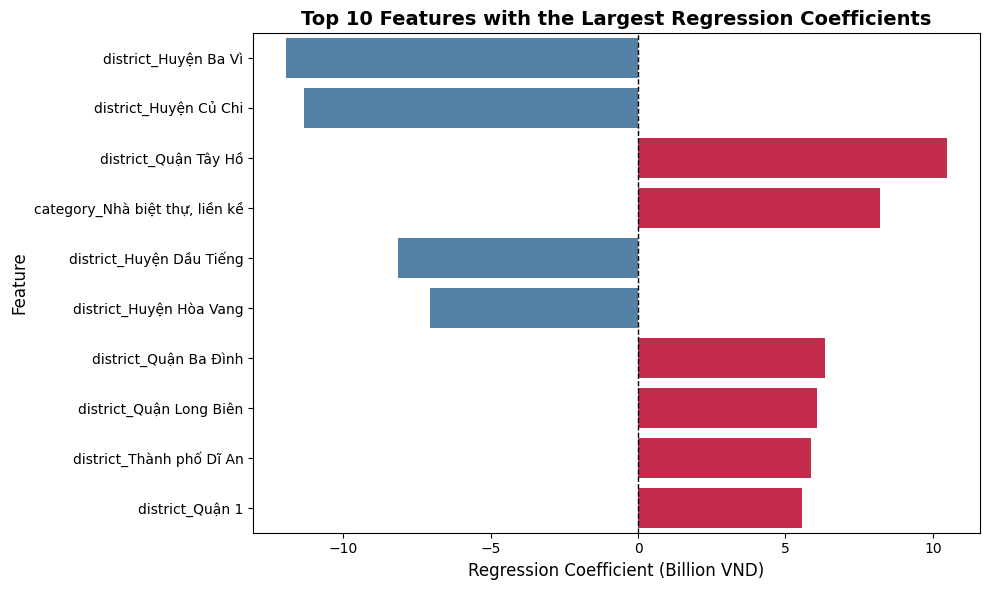

In [3]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

print("Training Linear Regression to extract weights...")

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

feature_names = preprocessor.get_feature_names_out()
coefficients = lr_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Feature'] = coef_df['Feature'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_10_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print("\nREGRESSION COEFFICIENTS TABLE (TOP 10):")
display(top_10_features[['Feature', 'Coefficient']])

plt.figure(figsize=(10, 6))
colors = top_10_features['Coefficient'].apply(lambda x: 'crimson' if x > 0 else 'steelblue')
sns.barplot(data=top_10_features, x='Coefficient', y='Feature', palette=colors.tolist())

plt.title('Top 10 Features with the Largest Regression Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Regression Coefficient (Billion VND)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) 

plt.tight_layout()
plt.savefig('linear_regression_coefficients.png', dpi=300)
plt.show()


# 4. Huấn luyện 5 Models (Gồm Linear Regression và Extra Trees)

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# CHỈ GIỮ LẠI 5 MÔ HÌNH NHƯ YÊU CẦU
models = {
    "Linear Regression": LinearRegression(),        
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

results =[]
print("Đang tiến hành huấn luyện 5 mô hình. Vui lòng đợi...\n")

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R-squared (R2)": r2,
        "RMSE (Billion VND)": rmse,
        "MAE (Billion VND)": mae
    })
    
    print(f"✔️ Đã train xong: {name}")

print("\nHoàn tất huấn luyện!")

Đang tiến hành huấn luyện 5 mô hình. Vui lòng đợi...

✔️ Đã train xong: Linear Regression
✔️ Đã train xong: Random Forest
✔️ Đã train xong: Extra Trees
✔️ Đã train xong: XGBoost
✔️ Đã train xong: LightGBM

Hoàn tất huấn luyện!


c:\Users\84333\AppData\Local\Programs\Thonny\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# 5. Đánh giá và hiển thị kết quả

In [5]:
# Chuyển kết quả thành DataFrame
results_df = pd.DataFrame(results)

# Sắp xếp các mô hình theo độ tốt (R-squared giảm dần)
results_df = results_df.sort_values(by="R-squared (R2)", ascending=False).reset_index(drop=True)

# In bảng kết quả
print("MODEL PERFORMANCE COMPARISON TABLE (SORTED FROM BEST TO WORST):")
display(results_df.style.background_gradient(cmap='Blues', subset=['R-squared (R2)'])
                  .background_gradient(cmap='Reds_r', subset=['RMSE (Billion VND)', 'MAE (Billion VND)']))

MODEL PERFORMANCE COMPARISON TABLE (SORTED FROM BEST TO WORST):


,Model,R-squared (R2),RMSE (Billion VND),MAE (Billion VND)
0,Extra Trees,0.848608,4.016815,2.089744
1,Random Forest,0.843933,4.078370,2.157832
2,XGBoost,0.843047,4.089936,2.326198
3,LightGBM,0.831225,4.241160,2.418388
4,Linear Regression,0.573204,6.744370,4.512717


# 6. Trực quan hóa so sánh các Model

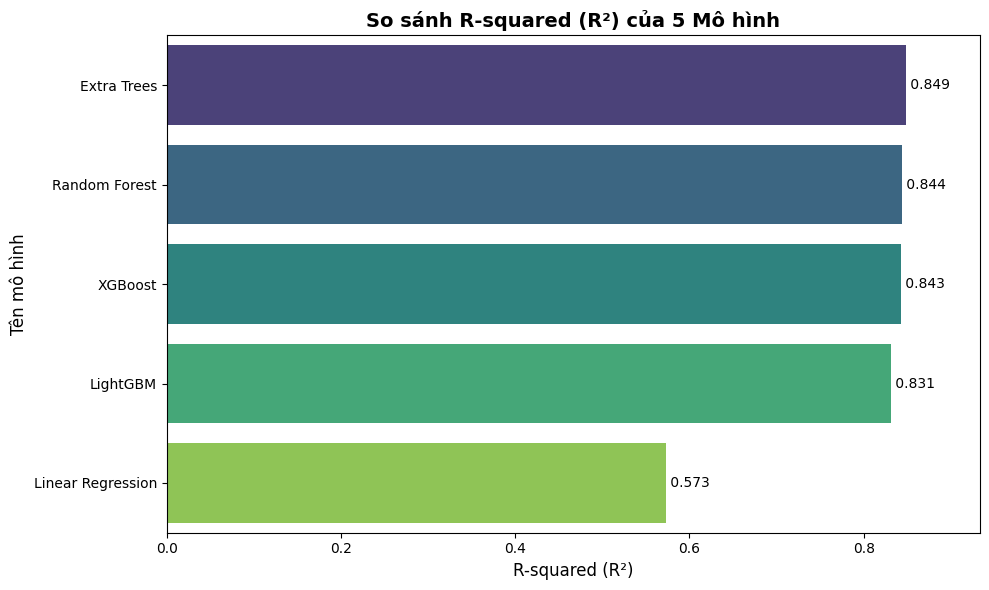

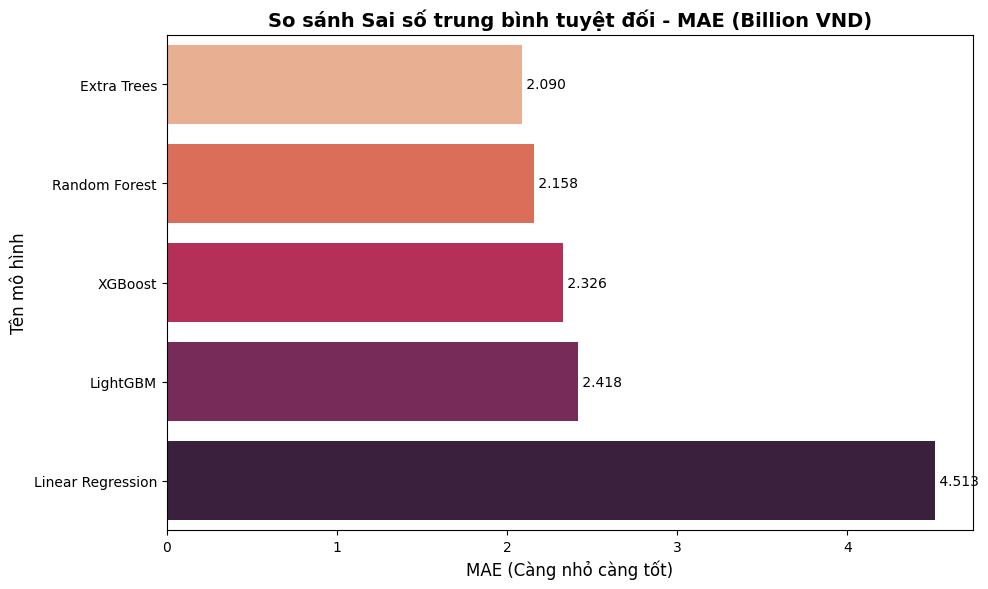

In [6]:
# VẼ BIỂU ĐỒ SO SÁNH ĐỘ CHÍNH XÁC (R-SQUARED)
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='R-squared (R2)', y='Model', hue='Model', palette='viridis', legend=False)
plt.title('So sánh R-squared (R²) của 5 Mô hình', fontsize=14, fontweight='bold')
plt.xlabel('R-squared (R²)', fontsize=12)
plt.ylabel('Tên mô hình', fontsize=12)

for index, value in enumerate(results_df['R-squared (R2)']):
    plt.text(value, index, f" {value:.3f}", va='center', fontsize=10)

plt.xlim(0, max(results_df['R-squared (R2)']) * 1.1)
plt.tight_layout()
plt.show()

# VẼ BIỂU ĐỒ SO SÁNH SAI SỐ MAE (Đã fix lỗi tên cột)
plt.figure(figsize=(10, 6))

# Sắp xếp lại df theo MAE tăng dần
results_df_mae = results_df.sort_values(by="MAE (Billion VND)", ascending=True)

sns.barplot(data=results_df_mae, x='MAE (Billion VND)', y='Model', hue='Model', palette='rocket_r', legend=False)

plt.title('So sánh Sai số trung bình tuyệt đối - MAE (Billion VND)', fontsize=14, fontweight='bold')
plt.xlabel('MAE (Càng nhỏ càng tốt)', fontsize=12)
plt.ylabel('Tên mô hình', fontsize=12)

for index, value in enumerate(results_df_mae['MAE (Billion VND)']):
    plt.text(value, index, f" {value:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()